# M5 Practice: Data Visualization with  Data

This practice notebook provides additional preparation for Assignment 5. 

## M5-L step guide
*Ctrl+F the `code text` to find the cell in the lab or the lesson.*

| # | Lab cell → what it wants | Where it's taught | Watch out / how to check |
|---|---|---|---|
| 0 | Part 1 cells + `#Import USGS flow data...` | Already filled in | Just run them. Should load 30,848 rows with no errors. |
| 1 | `#Create a month category...` → 3-letter months as a categorical, Jan→Dec | M5-1 "Categories & Labels": `#Create a month category with levels for all months` | Lab names are `USGS_flow` / `datetime` (lesson: `EPAair` / `Date`). Not M5-2's full-name version. **Check:** `.dtypes` shows `month_abb` as `category`. |
| 2 | `#Create a column indicating whether...` → Before (<1979) / During (1979–81) / After (>1981) | M5-1 same section: `#Create a depth class for NTL Data` (if/elif function + `.map()`), applied to `year` | Use the plain `.map()` version only. `pd.Categorical` and `pd.cut()` both keep an empty "During" level (no data 1971–85), which breaks Tasks 1, 4 and 5. **Check:** `.value_counts()` shows only Before and After. |
| 3 | `#Examine the dataframe` | M3-1 (same USGS data): `.shape`, `.info()`, `.describe()` | **Check:** month, year, season, month_abb and the status column are all there. |
| 4 | `# Set the default theme attributes` → whitegrid, notebook, colorblind-safe qualitative palette, font scale 0.8, two rc settings | M5-2 "Theme-level customization": the cell after "Alter some additional rc parameters"; rc table above it; palette names in the "Color" table | Palette and font scale inside `set_theme` aren't in the lessons → use the lab's set_theme hint link. `colorblind` covers both palette asks. **Check:** the next plot has a white background and grey grid. |
| T1 | `# Create a line plot of discharge over time` → `discharge_mean` over `datetime`, colored by status; title; no x label; y label "Discharge cfs"; legend "Construction Status" upper left, in a box | M5-1 "Lineplots"; M5-2 `g.set()` table (`xlabel=''` trick in `#Create a bar plot of mean PM2.5...`); M5-2 "Customizing Legends" | Save the plot as `g`. `loc='upper left'` alone sits on the y-axis numbers → add that cell's `bbox_to_anchor` line; `frameon` draws the box. **Check:** two colors with a gap in the middle. |
| T2 | `# Plot the number of records by year` → rows with a valid `discharge_min`, per year | M5-1 `#Count plot`; filter like the `.dropna(subset=...)` in M5-1 `#Create a long format version...`; height/aspect in M5-1 histogram "Things to try" | Filter before plotting. If every year shows about 365, the filter didn't work. Crowded year labels → M5-2 `g.set_xticklabels(rotation=45, ha='right')`. |
| T3 | `# Plot mean discharge by month` → typical value plus spread for each month | M5-1 `#Box plot` (median + spread) or `# Bar Plot` (mean + error bars) | Put `month_abb` on x. Turn on `log_scale` (commented out in the box-plot cell) or the boxes flatten. **Check:** 12 boxes, Jan→Dec. |
| T4 | `# Plot mean discharge by month, with separate...` → Task 3 plus `hue` = status, plot type point | M5-1 `#Point plot` | "During" in the legend means step 2 made a categorical. |
| T5 | `# Split the plot of monthly mean discharges into facets...` → one panel per status, stacked, saved as `g`, then merge the given cell below | M5-2 "Facet Plots" + `#Create a bar plot of mean PM2.5 ... facet for each year` | Use `col=` + `col_wrap=1`, not `row=` (`row=` makes the given cell crash). **Check:** 2 panels, Before on top. |

**✅ Questions: answer from the plots**
- **After T1 (useful?):** Is normal flow visible, or do the storm spikes set the scale? What does the 1971–85 gap do?
- **After T2:** Which years have bars at all?
- **After T4:** Where do the before and after lines differ most?
- **After T5:** Which makes before/after easier to compare: same axes (T4) or separate panels (T5)?

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1_2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [3]:
# 1_1 Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import calendar

In [4]:
# 1.2 Paths 
project_fldr = Path.cwd().parent
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'Processed_Key'

In [5]:
# 1.3 Dictionary to map month to season
month_to_season = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

#### 2. Ingest Data & Wrangle
* Import the processed USGS Flow dataset (`SGS_Site02085000_Flow_Processed.csv`) - located in the `Processed_Key` folder. 
    - Set the datetime column to be a datetime object
    - Create `month`, `year`, and `season` columns. (Use the `month_to_season` dictionary for the `season` column.)
* Create a `month_abb` column of abbreviated month names, set as a categorical field with levels for each month. 
* Add a column indicating whether the record occurred before, during, or after Falls Lake dam construction. (Construction started in 1979 and completed in 1981 - [Source](https://www.saw.usace.army.mil/portals/59/docs/recreation/fallslake/images/falls%20lake%20master%20plan%20june%2021%202013%20final.pdf))

In [6]:
#Import USGS flow data, deriving month, year, and season columns from datetime
USGS_flow = (
    pd.read_csv(
        processed_fldr/'USGS_Site02085000_Flow_Processed.csv',
        usecols = [
            'datetime', 
            'discharge_max','discharge_min','discharge_mean',
            'gage_height_max', 'gage_height_min', 'gage_height_mean',
            ],
        parse_dates=['datetime']
    )
    .assign(
        month = lambda df: df['datetime'].dt.month,
        year = lambda df: df['datetime'].dt.year,
        season = lambda df: df['month'].map(month_to_season)
    )
)


USGS_flow

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year,season
0,1928-01-01,NaN,NaN,74.00,NaN,NaN,NaN,1,1928,Winter
1,1928-01-02,NaN,NaN,61.00,NaN,NaN,NaN,1,1928,Winter
2,1928-01-03,NaN,NaN,56.00,NaN,NaN,NaN,1,1928,Winter
3,1928-01-04,NaN,NaN,54.00,NaN,NaN,NaN,1,1928,Winter
4,1928-01-05,NaN,NaN,48.00,NaN,NaN,NaN,1,1928,Winter
...,...,...,...,...,...,...,...,...,...,...
30843,2026-06-06,NaN,NaN,4.76,NaN,NaN,1.55,6,2026,Summer
30844,2026-06-07,NaN,NaN,4.71,NaN,NaN,1.55,6,2026,Summer
30845,2026-06-08,NaN,NaN,4.51,NaN,NaN,1.54,6,2026,Summer
30846,2026-06-09,NaN,NaN,4.38,NaN,NaN,1.53,6,2026,Summer


In [7]:
#Create a month category, with levels for each month
USGS_flow['month_abb'] = pd.Categorical(
    values=USGS_flow['datetime'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:],
)

In [8]:
#Create a column indicating whether the record was collected before, during, or after dam construction
def year_class(year):
    if year==1982: return 'After'
    elif year >= 1979: return 'Before'
    else: return 'During'

USGS_flow['year_class'] = USGS_flow['year'].map(year_class)

USGS_flow.describe()

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year
count,30848,5348.000000,5348.000000,30848.000000,5461.000000,5461.000000,11161.000000,30848.000000,30848.000000
mean,1976-12-18 14:32:55.518672,88.147554,30.462292,59.668283,2.123613,1.735719,1.987142,6.506256,1976.467129
min,1928-01-01 00:00:00,0.260000,0.090000,0.020000,0.890000,0.840000,0.870000,1.000000,1928.000000
25%,1949-02-10 18:00:00,7.230000,4.380000,9.200000,1.490000,1.380000,1.500000,4.000000,1949.000000
50%,1970-03-24 12:00:00,21.150000,12.600000,24.000000,1.830000,1.650000,1.810000,7.000000,1970.000000
75%,2005-04-29 06:00:00,59.800000,34.800000,53.325000,2.310000,2.030000,2.210000,10.000000,2005.000000
max,2026-06-10 00:00:00,4730.000000,1460.000000,8180.000000,17.020000,9.190000,15.040000,12.000000,2026.000000
std,NaN,282.801800,61.329289,158.730953,1.416646,0.587740,0.919247,3.449917,30.630066


In [9]:
#Examine the dataframe
USGS_flow.head(5)

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year,season,month_abb,year_class
0,1928-01-01,NaN,NaN,74.0,NaN,NaN,NaN,1,1928,Winter,Jan,During
1,1928-01-02,NaN,NaN,61.0,NaN,NaN,NaN,1,1928,Winter,Jan,During
2,1928-01-03,NaN,NaN,56.0,NaN,NaN,NaN,1,1928,Winter,Jan,During
3,1928-01-04,NaN,NaN,54.0,NaN,NaN,NaN,1,1928,Winter,Jan,During
4,1928-01-05,NaN,NaN,48.0,NaN,NaN,NaN,1,1928,Winter,Jan,During


#### 3. Craft your Seaborn Theme
* Set your theme to be based on Seaborn's `whitegrid` template.
* As we are working in notebook format, set the context to `notebook`.
* Explore [Seaborn's palettes](https://seaborn.pydata.org/tutorial/color_palettes.html#qualitative-color-palettes) and set your palette to one of the qualitative palettes. 
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set two of the theme's runtime configuration (`rc`) options. ([Hint](https://seaborn.pydata.org/generated/seaborn.axes_style.html))

In [10]:
# Set the default theme attributes
sns.set_theme(style='whitegrid')


#### 📊Task 1: Plot discharge over time
* Create a line plot showing values of mean discharge over the span of the data we have. 
* Color the line by dam construction status. 
* Give the plot a title. 
* Remove the x-axis label (set it to an empty string: `""`)
* Set the y-axis label to "Discharge cfs"
* Title the legend "Construciton Status"
* Place the legend in the upper left corner, enclosed in a box. 

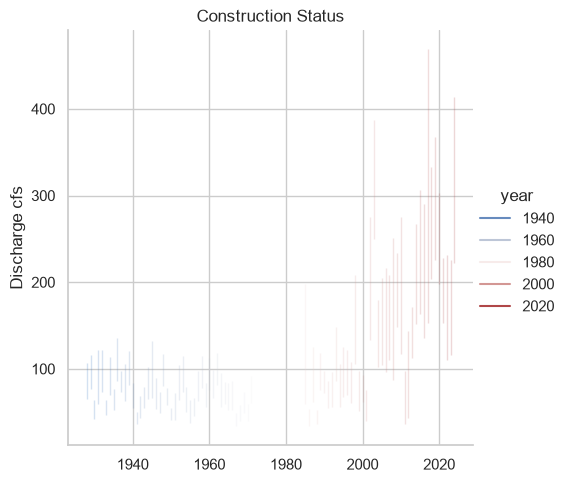

In [21]:
# Create a line plot of discharge over time
sns.relplot(
    data=USGS_flow.loc[
        (USGS_flow['discharge_mean'].isin(range(0,8000))) &
        (USGS_flow['year'].isin(range(1927,2025)))
    ],
    x='year',
    y='discharge_mean',
    kind='line',
    hue='year',
    palette='vlag',
).set(
    title = "Construction Status",
    xlabel = " ",
    ylabel = "Discharge cfs",
);


#### ✅ Question
**Would you say this is a useful plot? Why or why not? What might improve it?**
> **Answer**:  
>  

---
#### 📊Task 2: Plot the number of records with valid minimum discharge values by year
* Determine which plot function to use: `relplot()`, `displot()`, or `catplot()`
* Determine which subplot function to use (e.g. "scatterplot" for relplot, "swarmplot" for catplot).
* Craft your plot to use the appropriate dataset and which variables to assign to which axes.
* Adjust the style of your plot to look tidy and professional:
    - Set the height and aspect of your plot to ensure it's clear and uses space accordingly.
    - Give your plot a title, and set axis labels appropriately. (Note: "Year' is an optional label when obvious.)

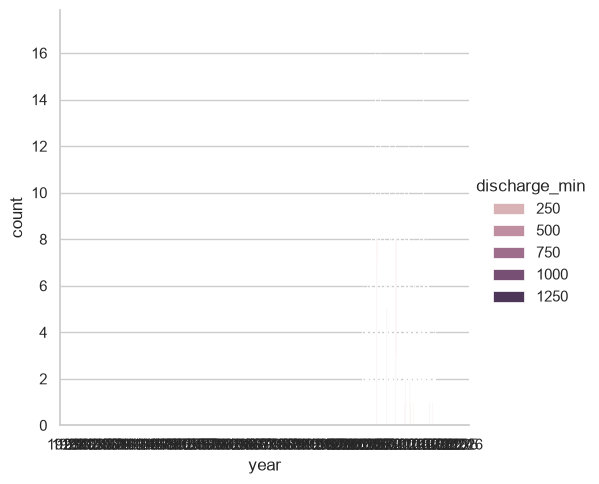

In [12]:
# Plot the number of records by year
sns.catplot(
    data=USGS_flow,
    hue='discharge_min',
    x ='year',
    kind = 'count',
    linewidth = 0.5,
    
)

##### ✅Question:
**What does this plot reveal about when the USGS recorded minimum and maximum discharge?**
> **Answer**
>

---
#### 📊Task 3: Plot the distribution of mean discharge by month
We want to examine monthly trends in discharge: is more water flowing through the sites some months than others? Is there a trend across months? To explore this, construct a plot that displays the typical (mean or median) discharge in a given month as well as some indication of the range of values. As before, make this plot tidy and professional. 


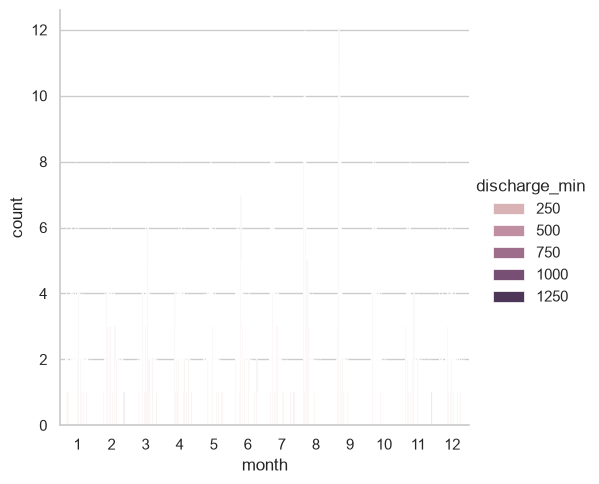

In [13]:
# Plot mean discharge by month
sns.catplot(
    data=USGS_flow,
    hue='discharge_min',
    x ='month',
    kind = 'count',
    linewidth = 0.5,
    
)

---
#### 📊Task 4: Alter the above plot to compare trends before and after dam construction
* Copy and paste your above code into the code cell below
* Color the monthly mean discharge values by the dam construction category.
* Change your plot type to `point`.

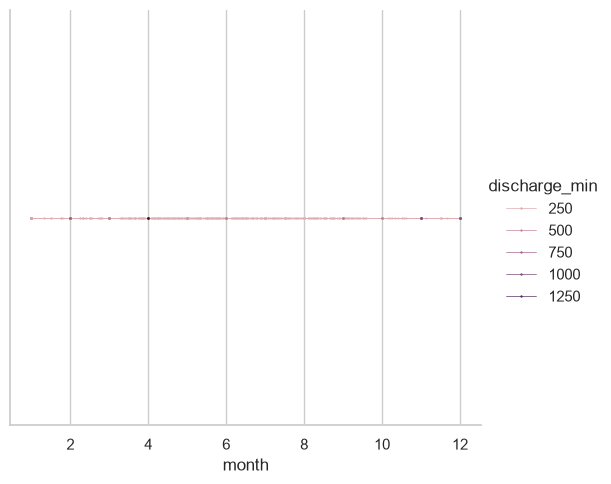

In [14]:
# Plot mean discharge by month, with separate plot features for records before and after dam construction
sns.catplot(
    data=USGS_flow,
    hue='discharge_min',
    x ='month',
    kind = 'point',
    linewidth = 0.5,
    
)

##### ✅Question:
**Does this plot suggest any differences in monthly discharge patterns before/after the dam?**
> **Answer**
>

---
#### 📊Task 5: Split before/after dam construction as separate *facets*
* Show separate plots of monthly mean discharge
* Stack the plots vertically
* Assing the facetgrid object produced by your plotting to the variable `g`
* Append the code in the subsequent code cell to set titles and axes labels. (Note that facet plots produce a list of facetgrid objects that we can access individually).

In [15]:
# Split the plot of monthly mean discharges into facets of before and after construction
USGS_flow.columns

Index(['datetime', 'discharge_max', 'discharge_min', 'discharge_mean',
       'gage_height_max', 'gage_height_min', 'gage_height_mean', 'month',
       'year', 'season', 'month_abb', 'year_class'],
      dtype='str')

In [16]:
# Merge this code cell with your code cell above 

#g = sns.catplot(
    #data=USGS_flow,
   # x='year',
    #y='discharge_min',
    #kind='bar',
    #col='year',
#)

#g.axes[0].set(
    #title = 'Monthly discharge: Before Dam Construction',
    #xlabel= '',
    #ylabel= 'Discharge (cfs)'
    #)

#g.axes[1].set(
    #title = 'Monthly discharge :After Dam Construction',
    #xlabel= '',
    #ylabel= 'Discharge (cfs)'
    #)

# Show the plot


##### ✅Question:
**Which of the last two plots shows the data more effectively?**
> **Answer**
>